**Этот блокнот является упражнением из курса [Computer Vision](https://www.kaggle.com/learn/computer-vision). Вы можете обратиться к учебному пособию по [этой ссылке](https://www.kaggle.com/ryanholbrook/the-convolutional-classifier).**

---


<blockquote style="margin-right:auto; margin-left:auto; padding: 1em; margin:24px;">
    <strong>Ускорьте обучение с помощью Kaggle GPU!</strong><br>
Знаете ли вы, что Kaggle предоставляет бесплатное время с GPU-ускорителем? Вы можете ускорить обучение нейронных сетей в этом курсе, переключившись на <strong>GPU</strong> в опции <em>Accelerator</em> справа. (Возможно, он уже включён.) Следует учитывать два момента:
<ul>
<li>Изменение опции <em>Accelerator</em> приведёт к перезапуску сессии блокнота. Вам нужно будет заново выполнить весь подготовительный код.
<li>Одновременно может быть активна только одна GPU-сессия, поэтому обязательно завершите работу блокнота после выполнения упражнения.
</ul>
</blockquote>

# Введение #

В учебном пособии мы увидели, как построить классификатор изображений, присоединив голову из полносвязных слоёв к предварительно обученной основе. Основа, которую мы использовали, была из модели **VGG16**. Мы заметили, что архитектура VGG16 была склонна к переобучению на этом наборе данных. В ходе этого курса вы узнаете несколько способов улучшить эту первоначальную попытку.

Первый способ, который вы увидите, — использование основы, более подходящей для данного набора данных. Основа этой модели называется **InceptionV1** (также известна как GoogLeNet). InceptionV1 была одной из первых победительниц соревнования ImageNet. Один из её преемников, InceptionV4, находится на переднем крае современных технологий.

Для начала выполните ячейку кода ниже, чтобы настроить всё необходимое.

In [6]:
# Настройка системы обратной связи
# Импорты
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Воспроизводимость
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Установка стандартных настроек Matplotlib
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    './data/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=8,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    './data/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=8,
    shuffle=False,
)

# Конвейер данных
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


Found 5117 files belonging to 2 classes.
Found 5051 files belonging to 2 classes.


Модель **InceptionV1**, предварительно обученная на ImageNet, доступна в репозитории [TensorFlow Hub](https://www.tensorflow.org/hub/), но мы загрузим её из локальной копии. Выполните эту ячейку, чтобы загрузить InceptionV1 в качестве вашей основы.

In [7]:
# import tensorflow_hub as hub

pretrained_base = tf.keras.models.load_model(
    './data/cv-course-models/inceptionv1'
)

# 1) Определите предварительно обученную основу #

Теперь, когда у вас есть предварительно обученная основа для извлечения признаков, решите, должна ли эта основа быть обучаемой или нет.

In [8]:
# ВАШ_КОД_ЗДЕСЬ
pretrained_base.trainable = False


In [ ]:
# Строки ниже дадут подсказку или код решения
#q_1.hint()
#q_1.solution()

# 2) Присоедините голову #

Теперь, когда основа определена для извлечения признаков, создайте голову из полносвязных (`Dense`) слоёв для выполнения классификации, следуя этой диаграмме:

<figure>
<img src="./img/i5VU7Ry.png" alt="Диаграмма полносвязной головы.">
</figure>


In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    pretrained_base,
    layers.Flatten(),
    # ВАШ КОД ЗДЕСЬ. Присоедините голову из полносвязных слоёв.
    layers.Dense(6, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

In [ ]:
# Строки ниже дадут подсказку или код решения
#q_2.hint()
#q_2.solution()

# 3) Обучение #

Перед обучением модели в Keras необходимо указать *оптимизатор* для выполнения градиентного спуска, *функцию потерь*, которую нужно минимизировать, и (опционально) *метрики производительности*. Алгоритм оптимизации, который мы будем использовать в этом курсе, называется ["Adam"](https://keras.io/api/optimizers/adam/). Он обычно хорошо работает независимо от типа решаемой задачи.

Однако функция потерь и метрики должны соответствовать типу решаемой задачи. Наша задача — это задача **бинарной классификации**: `Car` (автомобиль) кодируется как 0, а `Truck` (грузовик) — как 1. Выберите подходящую функцию потерь и соответствующую метрику точности для бинарной классификации.

In [10]:
# ВАШ КОД ЗДЕСЬ: какую функцию потерь следует использовать для задачи
# бинарной классификации? (Ваш ответ для каждого должен быть строкой.)
optimizer = tf.keras.optimizers.Adam(epsilon=0.01)
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)


In [ ]:
# Строки ниже дадут подсказку или код решения
#q_3.hint()
#q_3.solution()

In [11]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=30,
)

Epoch 1/30
640/640 [==============================] - 20s 19ms/step - loss: 0.4685 - binary_accuracy: 0.7717 - val_loss: 0.3756 - val_binary_accuracy: 0.8382
Epoch 2/30
640/640 [==============================] - 17s 26ms/step - loss: 0.3719 - binary_accuracy: 0.8378 - val_loss: 0.3626 - val_binary_accuracy: 0.8428
Epoch 3/30
640/640 [==============================] - 9s 15ms/step - loss: 0.3472 - binary_accuracy: 0.8499 - val_loss: 0.3438 - val_binary_accuracy: 0.8527
Epoch 4/30
640/640 [==============================] - 9s 14ms/step - loss: 0.3299 - binary_accuracy: 0.8568 - val_loss: 0.3468 - val_binary_accuracy: 0.8519
Epoch 5/30
640/640 [==============================] - 9s 14ms/step - loss: 0.3166 - binary_accuracy: 0.8638 - val_loss: 0.3364 - val_binary_accuracy: 0.8559
Epoch 6/30
640/640 [==============================] - 9s 14ms/step - loss: 0.3039 - binary_accuracy: 0.8689 - val_loss: 0.3387 - val_binary_accuracy: 0.8567
Epoch 7/30
640/640 [==============================] - 9s

Выполните ячейку ниже, чтобы построить графики кривых потерь и метрик для этого сеанса обучения.

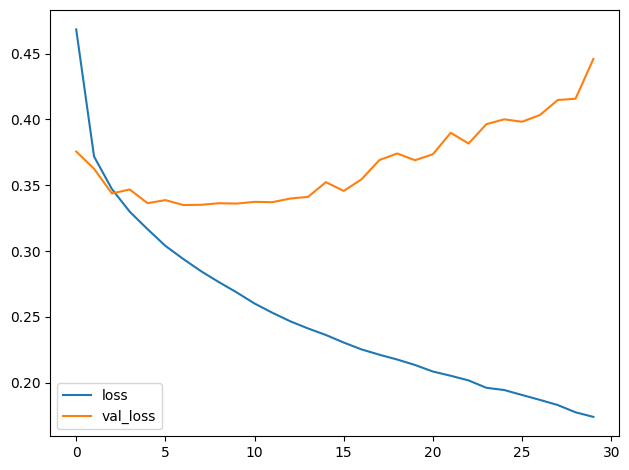

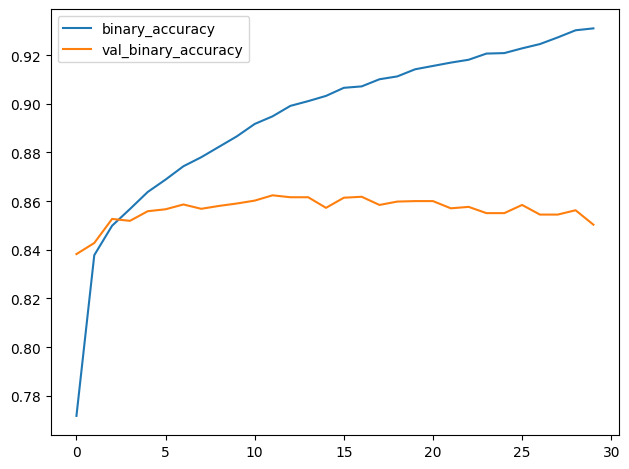

In [12]:
import pandas as pd
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

# 4) Изучите потери и точность #

Замечаете ли вы разницу между этими кривыми обучения и кривыми для VGG16 из учебного пособия? О чём говорит эта разница в том, чему научилась эта модель (InceptionV2) по сравнению с VGG16? Есть ли аспекты, в которых одна модель лучше другой? Хуже?

После того как вы обдумаете это, выполните ячейку ниже, чтобы увидеть ответ.

In [ ]:
# Посмотреть решение (Выполните эту ячейку, чтобы получить оценку!)
Правильно:

То, что потери при обучении и валидации остаются примерно на одном уровне, 
свидетельствует о том, что модель не просто запоминает обучающие данные, а 
скорее изучает общие свойства двух классов. Но поскольку потери этой модели 
выше, чем у модели VGG16, вполне вероятно, что она не до конца справляется с 
задачей и ей не помешала бы дополнительная вычислительная мощность.

# Заключение #

На этом первом уроке вы изучили основы **свёрточных классификаторов изображений**: они состоят из **основы** для извлечения признаков из изображений и **головы**, которая использует эти признаки для определения класса изображения. Вы также увидели, как построить классификатор с помощью **трансферного обучения** на предварительно обученной основе.

# Продолжайте обучение #

Переходите к [**Уроку 2**](https://www.kaggle.com/ryanholbrook/convolution-and-relu) для подробного изучения того, как основа выполняет извлечение признаков. (Это действительно круто!)

---




*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*